# PUF Metric Bar Plots
Visualize PUF reliability and metric comparisons using bar charts.

## Reproduce this notebook
1. Install dependencies from `pypuf/requirements.txt`.
2. Open this file in Jupyter.
3. Run each cell sequentially to generate the models and plots.

## Example output
![Representative output](graphs_metrics/ArbiterPUF_metrics_vs_temperature.png)


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 16,        # base font
    "axes.titlesize": 20,   # plot title
    "axes.labelsize": 18,   # axis labels
    "xtick.labelsize": 16,  # x tick labels
    "ytick.labelsize": 16,  # y tick labels
    "legend.fontsize": 16   # legend text
})

In [13]:
df = pd.read_csv("multi_constant_reliability_analysis.csv")
df.head()

,PUF Type,Sweep Type,Constant Parameter,Max Reliability,Min Reliability,Median Reliability,Slope
0,ArbiterPUF,Temperature Sweep,Vdd=1.0,0.986182,0.981795,0.984216,0.000073
1,ArbiterPUF,Temperature Sweep,Vdd=1.5,0.977501,0.970458,0.974429,0.000118
2,ArbiterPUF,Temperature Sweep,Vdd=2.0,0.968507,0.958410,0.964115,0.000168
3,ArbiterPUF,Temperature Sweep,Vdd=2.5,0.958882,0.946146,0.953203,0.000210
4,ArbiterPUF,Voltage Sweep,T=20,0.981795,0.943747,0.963376,-0.023853


In [14]:
# Order from the provided figure
puf_order = [
    "ArbiterPUF",
    "FeedForwardArbiterPUF",
    "InterposePUF",
    "LightweightSecurePUF",
    "PermutationPUF",
    "XORArbiterPUF",
    "XORFeedForwardArbiterPUF"
]

# Abbreviations for plotting
puf_labels = [
    "Arbiter",
    "FF-Arbiter",
    "Interpose",
    "Lightweight",
    "Permutation",
    "XOR-Arbiter",
    "XOR-FF-Arbiter"
]

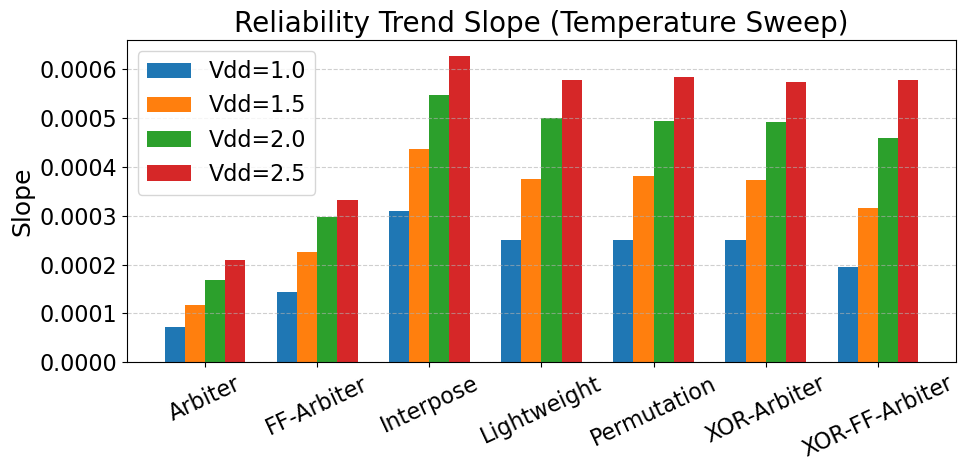

In [15]:
temp_df = df[df["Sweep Type"] == "Temperature Sweep"].copy()

# extract Vdd numeric value
temp_df["Vdd"] = temp_df["Constant Parameter"].str.replace("Vdd=", "").astype(float)

temp_df = temp_df.set_index("PUF Type").loc[puf_order].reset_index()

vdds = sorted(temp_df["Vdd"].unique())

x = np.arange(len(puf_order))
width = 0.18

plt.figure(figsize=(10,5))

for i, v in enumerate(vdds):
    slopes = temp_df[temp_df["Vdd"] == v]["Slope"].values
    plt.bar(x + i*width, slopes, width, label=f"Vdd={v}")

plt.xticks(x + width*1.5, puf_labels, rotation=25)
plt.ylabel("Slope")
plt.title("Reliability Trend Slope (Temperature Sweep)")
plt.legend()
plt.grid(axis='y', linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

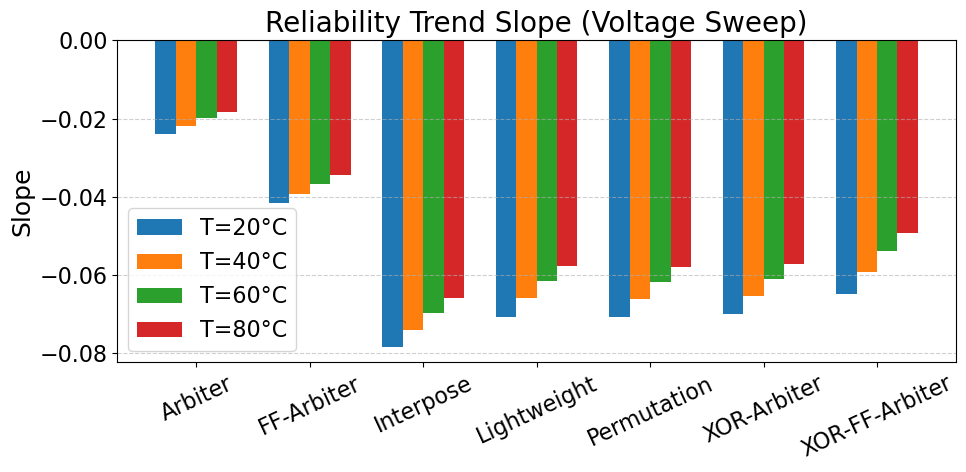

In [16]:
volt_df = df[df["Sweep Type"] == "Voltage Sweep"].copy()

# extract temperature
volt_df["Temp"] = volt_df["Constant Parameter"].str.replace("T=", "").astype(int)

volt_df = volt_df.set_index("PUF Type").loc[puf_order].reset_index()

temps = sorted(volt_df["Temp"].unique())

x = np.arange(len(puf_order))
width = 0.18

plt.figure(figsize=(10,5))

for i, t in enumerate(temps):
    slopes = volt_df[volt_df["Temp"] == t]["Slope"].values
    plt.bar(x + i*width, slopes, width, label=f"T={t}°C")

plt.xticks(x + width*1.5, puf_labels, rotation=25)
plt.ylabel("Slope")
plt.title("Reliability Trend Slope (Voltage Sweep)")
plt.legend()
plt.grid(axis='y', linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()